In [38]:
from matplotlib.image import imread
import matplotlib.pyplot as plt

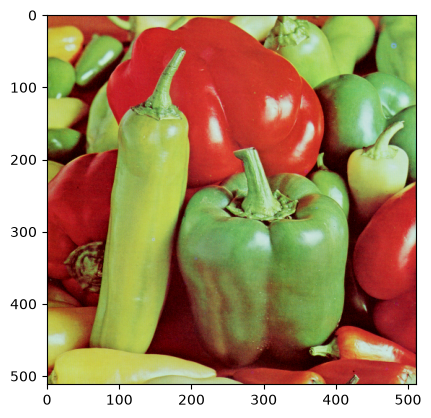

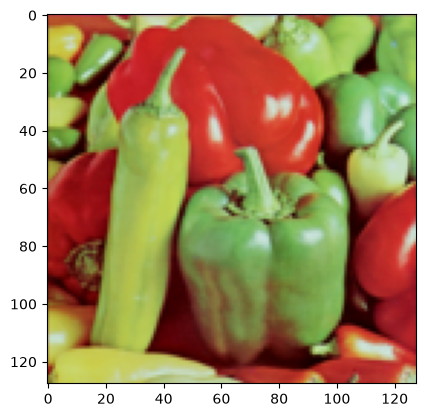

In [39]:
A = imread('../data/peppers-large.tiff')
plt.imshow(A)
plt.show()

A_small = imread('../data/peppers-small.tiff')
plt.imshow(A_small) 
plt.show()


In [40]:
import numpy as np

In [ ]:
def k_means_for_compression(number_of_clusters, X):
    width, height, vector = X.shape
    rng = np.random.default_rng()
    mus = rng.integers(0, 255, (number_of_clusters, vector))
    # mus = rng.random((number_of_clusters, vector))
    new_mus = mus.copy()
    clusters = np.zeros(shape=(width, height))
    eps = 1e-20
        
    while True:
        for w in range(width):
            for h in range(height):
                x_i = X[w, h]
                x_i_minus_mus = x_i - mus
                x_i_minus_mu_norms = np.linalg.norm(x_i_minus_mus, axis=1)
                clusters[w, h] = np.argmin(x_i_minus_mu_norms)
                
        for j in range(number_of_clusters):
            arr_j = []

            for w in range(width):
                for h in range(height):
                    if clusters[w, h] == j:
                        arr_j.append(X[w, h])
            
            arr_j = np.array(arr_j)
            new_mus[j] = ((1 + np.sum(arr_j, axis=0)) / (arr_j.shape[0] + number_of_clusters))
        
        if np.linalg.norm(mus - new_mus) ** 2 > eps:
            mus = new_mus.copy()
        else:
            break
    
    
    compressed_X = X.copy()
    for w in range(width):
        for h in range(height):
            compressed_X[w, h] = mus[int(clusters[w, h])]

    return compressed_X.astype(int)

A_compressed = k_means_for_compression(16, A)
plt.imshow(A_compressed)
plt.show()



KeyboardInterrupt: 

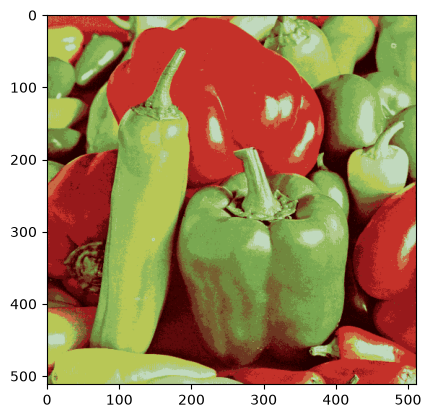

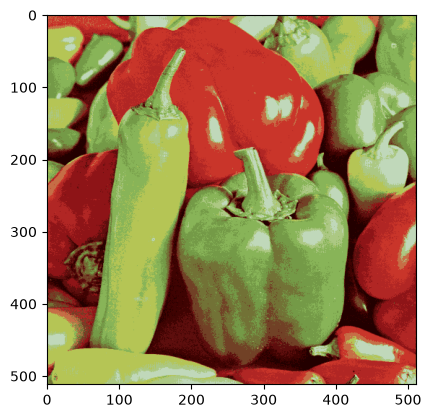

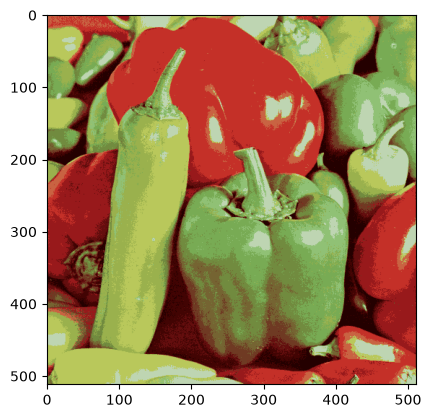

In [ ]:
def k_means_for_compression_fast(number_of_clusters, X, max_iter=None):
    original_shape = X.shape
    X = X.reshape(-1, X.shape[2])
    rng = np.random.default_rng()
    mus = rng.integers(0, 255, (number_of_clusters, X.shape[1]))
    clusters = np.zeros(X.shape[0])
    new_mus = mus.copy()
    eps = 1e-3
    clusters_args = np.arange(number_of_clusters).reshape(-1, 1)

    iter = 0
    while True:
        if max_iter is not None and iter >= max_iter:
            break

        clusters = np.argmin(np.linalg.norm(X[:, np.newaxis, :] - mus, axis=2), axis=1)

        for j in range(number_of_clusters):
            arr_j = X[clusters == j]
            new_mus[j] = (np.sum(arr_j, axis=0) + 1) / (arr_j.shape[0] + number_of_clusters)
        

        if np.linalg.norm(mus - new_mus) ** 2 > eps:
            mus = new_mus.copy()
            iter += 1
        else:
            break

    compressed_X = (mus[clusters]).reshape(original_shape)
    return compressed_X.astype(int)


A_compressed = k_means_for_compression_fast(16, A, 10)
plt.imshow(A_compressed)
plt.show()


A_compressed = k_means_for_compression_fast(16, A, 100)
plt.imshow(A_compressed)
plt.show()

A_compressed = k_means_for_compression_fast(16, A)
plt.imshow(A_compressed)
plt.show()
